In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
    !pip install --no-deps --upgrade "torchao>=0.16.0"


In [3]:
from unsloth import FastLanguageModel
from huggingface_hub import hf_hub_download
from peft import set_peft_model_state_dict
def load_adapter(repo):
   model,tokenizer=FastLanguageModel.from_pretrained(
        model_name="unsloth/Qwen3-0.6B",
        load_in_4bit=True,
        max_seq_length=2048,
   )
   model=FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                        "gate_proj", "up_proj", "down_proj"],
        lora_alpha=32,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=3407,
        use_rslora=False,
        loftq_config=None,
    )
   try:
        model_weights=hf_hub_download(
            repo_id=f"Srishtik/{repo}",
            filename="adapter_model.safetensors"
        )
   except:
        model_weights=hf_hub_download(
            repo_id=f"Srishtik/{repo}",
            filename="adapter_model.bin"
        )
   from safetensors.torch import load_file
   state_dict=load_file(model_weights)
   set_peft_model_state_dict(model,state_dict)
   return model
    

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
adapter_1=load_adapter("3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-1")

==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/576M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/237 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


Unsloth 2026.6.9 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [7]:
adapter_2=load_adapter("3-adapter-merge-gemma-3-270m-non-reasoning-finetome-17k-2")

==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [8]:
adapter_3=load_adapter("3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-17k-3")

==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [9]:
adapter_full=load_adapter("3-adapter-merge-qwen-3-0.6B-non-reasoning-finetome-51k")

==((====))==  Unsloth 2026.6.9: Fast Qwen3 patching. Transformers: 5.0.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.34. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

unsloth/qwen3-0.6b-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


adapter_model.safetensors:   0%|          | 0.00/40.4M [00:00<?, ?B/s]

In [10]:
import torch

def extract_all_deltas(model):
    deltas = {}
    n_blocks = len(model.base_model.model.model.layers)
    
    for i in range(n_blocks):
        block = model.base_model.model.model.layers[i]
        
        for name, module in block.named_modules():
            if hasattr(module, 'lora_A') and hasattr(module, 'lora_B'):
                try:
                    A = module.lora_A.default.weight.detach().float()
                    B = module.lora_B.default.weight.detach().float()
                    scale = module.scaling.get("default", 1.0)
                    delta_W = scale * (B @ A)
                    deltas[f"layer_{i}.{name}"] = delta_W  # flat key
                except Exception as e:
                    print(f"Block {i} | {name} | error: {e}")
    
    return deltas
                
        

In [11]:
deltas_1=extract_all_deltas(adapter_1)

In [12]:
deltas_2=extract_all_deltas(adapter_2)

In [13]:
deltas_3=extract_all_deltas(adapter_3)

In [14]:
deltas_full=extract_all_deltas(adapter_full)

In [15]:
len(deltas_2)

196

In [16]:
for key,val in deltas_2.items():
    print(key)
    print(val)
    break

layer_0.self_attn.q_proj
tensor([[-2.1503e-04, -2.1383e-04, -1.1397e-04,  ..., -2.8917e-04,
         -1.3817e-04,  1.7209e-04],
        [-6.8153e-05,  2.2225e-04,  2.7345e-04,  ...,  7.6236e-05,
         -4.4794e-05, -2.2687e-04],
        [-6.0834e-05, -4.2409e-04, -4.1979e-04,  ..., -5.9165e-04,
          5.6022e-05,  4.8277e-04],
        ...,
        [ 5.8677e-05,  7.6803e-04,  1.7427e-04,  ...,  4.6632e-04,
         -2.6751e-04, -2.2917e-04],
        [-2.6495e-04, -1.0543e-05,  4.3032e-04,  ...,  2.0358e-04,
         -9.7834e-05, -6.6936e-05],
        [-3.5930e-04, -1.6196e-04,  3.0013e-04,  ..., -6.0820e-06,
         -1.6073e-04,  3.8300e-04]], device='cuda:0')


In [18]:
# Check first item
key, val = list(deltas_2.items())[0]
print(key)
print(type(val))
print(val)

layer_0.self_attn.q_proj
<class 'torch.Tensor'>
tensor([[-2.1503e-04, -2.1383e-04, -1.1397e-04,  ..., -2.8917e-04,
         -1.3817e-04,  1.7209e-04],
        [-6.8153e-05,  2.2225e-04,  2.7345e-04,  ...,  7.6236e-05,
         -4.4794e-05, -2.2687e-04],
        [-6.0834e-05, -4.2409e-04, -4.1979e-04,  ..., -5.9165e-04,
          5.6022e-05,  4.8277e-04],
        ...,
        [ 5.8677e-05,  7.6803e-04,  1.7427e-04,  ...,  4.6632e-04,
         -2.6751e-04, -2.2917e-04],
        [-2.6495e-04, -1.0543e-05,  4.3032e-04,  ...,  2.0358e-04,
         -9.7834e-05, -6.6936e-05],
        [-3.5930e-04, -1.6196e-04,  3.0013e-04,  ..., -6.0820e-06,
         -1.6073e-04,  3.8300e-04]], device='cuda:0')


In [ ]:
!git clone https://github.com/SrishtikSekar/Lora_Adapter_Merging.git

In [ ]:
!ls


In [ ]:
%cd Lora_Adapter_Merging

In [ ]:
!ls

In [ ]:
!git pull origin main

# Model Comparision

## 1) Frobenius Norm

In [ ]:
from frobenius_norm import frobenius_norm


In [19]:
def frobenius_norm(deltas):
    model_norms={}
    for layer_name,delta in deltas.items():
        model_norms[layer_name]=delta.norm(p="fro").item()
    import matplotlib.pyplot as plt

    layers=list(model_norms.keys())
    values=list(model_norms.values())

    plt.figure(figsize=(14,6))
    plt.plot(range(len(values)),values)
    plt.xticks(range(len(values)),layers,rotation=90)
    plt.ylabel("Frobenius Norm")
    plt.xlabel("Layer")
    plt.title("Layer wise LoRA Update Strength")
    plt.tight_layout()
    plt.show()


### 1.1) Adapter_1 model

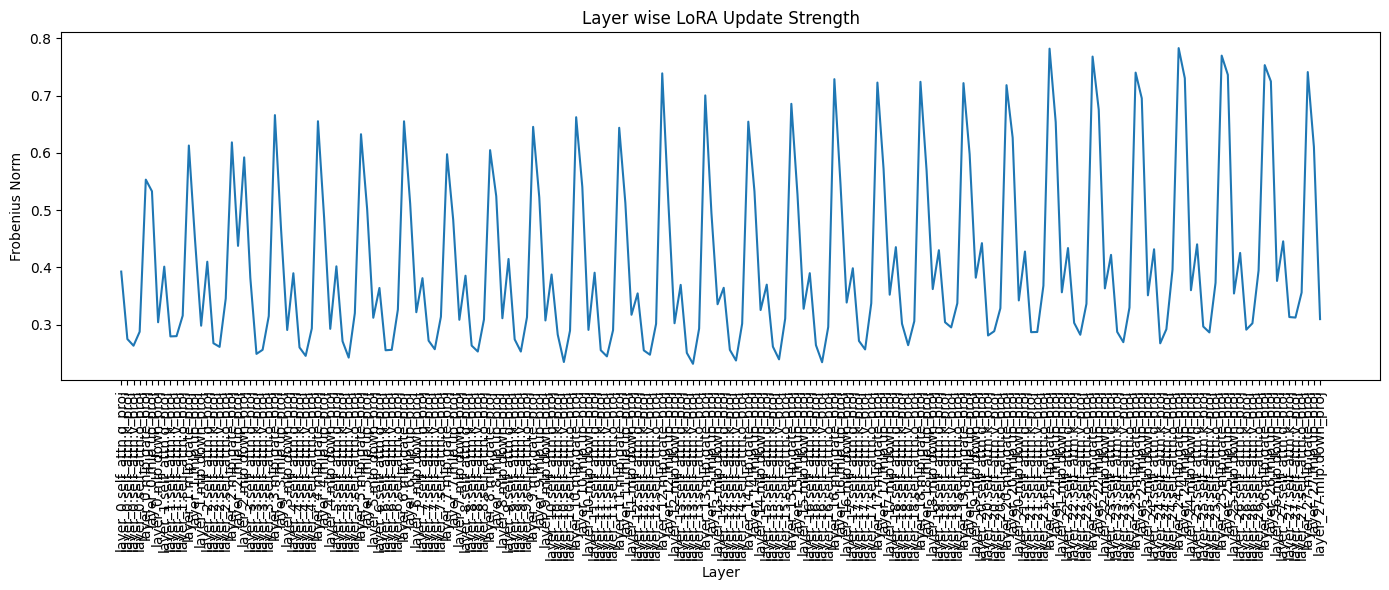

In [20]:
frobenius_norm(deltas_1)

### 1.2) Adapter_2 model

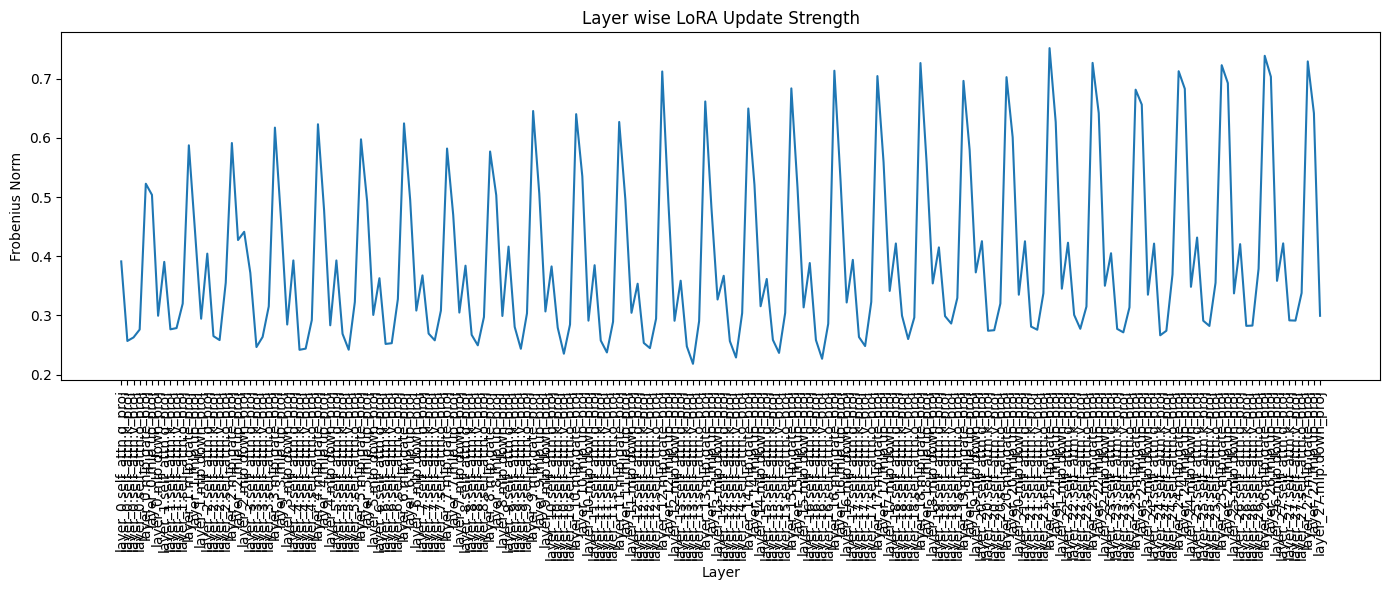

In [21]:
frobenius_norm(deltas_2)

### 1.3) Adapter_3 model

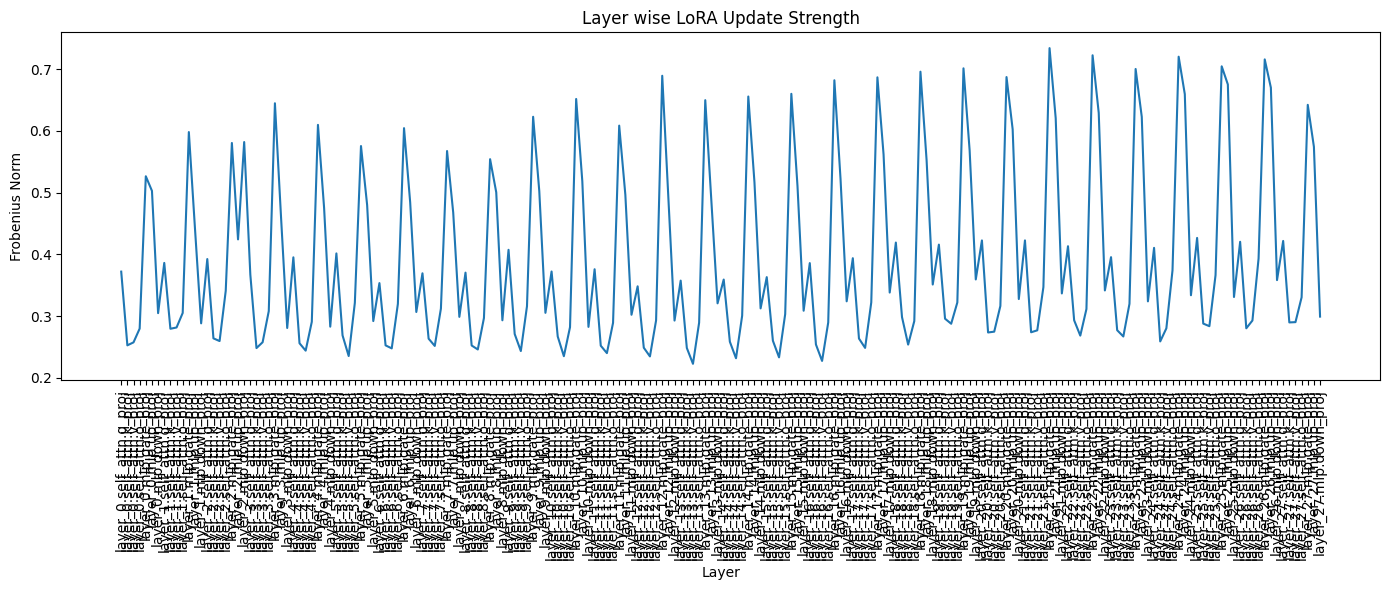

In [22]:
frobenius_norm(deltas_3)

## 1.4) Full adapter model

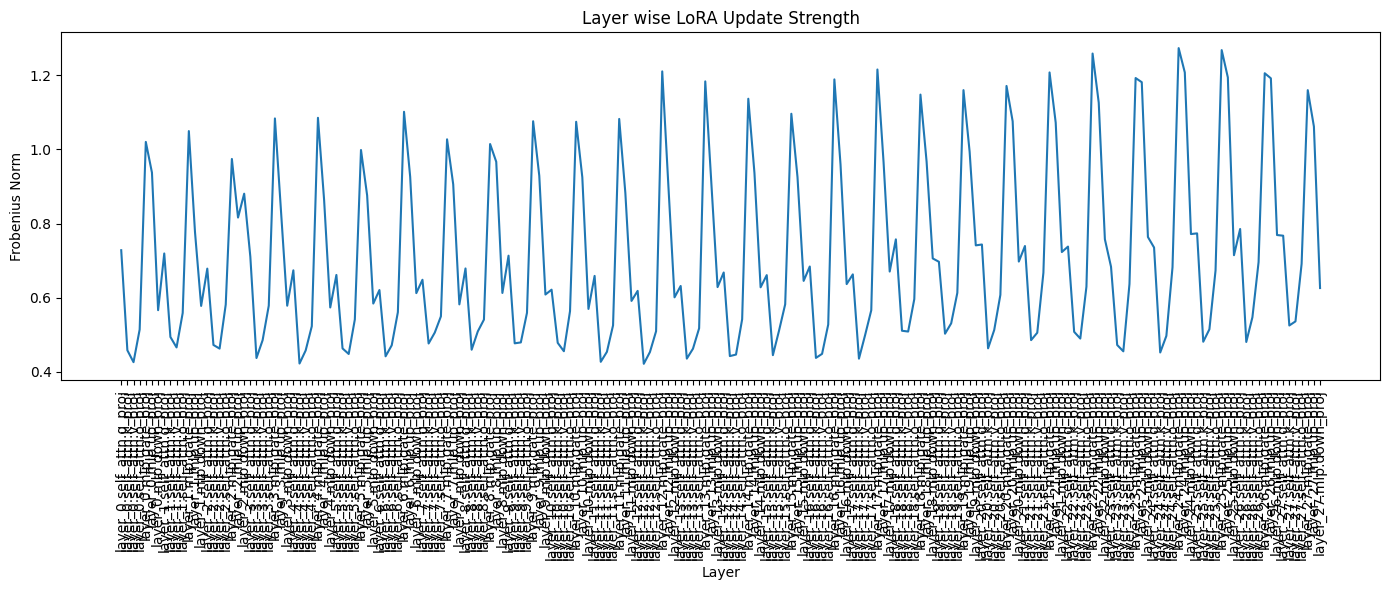

In [23]:
frobenius_norm(deltas_full)

## 2) Cosine Similarity

In [24]:
import torch
import pandas as pd

import torch
import pandas as pd


def true_cosine_similarity(delta1, delta2):

    v1 = delta1.flatten().to(torch.float64)
    v2 = delta2.flatten().to(torch.float64)

    dot_product = torch.dot(v1, v2)

    norm1 = torch.norm(v1)
    norm2 = torch.norm(v2)

    cosine = dot_product / (norm1 * norm2)

    return cosine.item()


def compute_all_layer_cosines(adapter1_deltas, adapter2_deltas):

    results = []

    common_layers = set(adapter1_deltas.keys()) & set(adapter2_deltas.keys())

    for layer_name in sorted(common_layers):

        delta1 = adapter1_deltas[layer_name]
        delta2 = adapter2_deltas[layer_name]

        cosine = true_cosine_similarity(delta1, delta2)

        results.append({
            "layer": layer_name,
            "cosine_similarity": cosine
        })

    return pd.DataFrame(results)


# Compute similarities
cosine_df1 = compute_all_layer_cosines(
    deltas_full,
    deltas_1,
)
cosine_df2 = compute_all_layer_cosines(
    deltas_full,
    deltas_2,
)
cosine_df3 = compute_all_layer_cosines(
    deltas_full,
    deltas_3,
)




### 2.1) Comparision between full deltas and delta 1

In [25]:
print(cosine_df1.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.643506
    layer_0.mlp.gate_proj           0.634173
      layer_0.mlp.up_proj           0.665483
 layer_0.self_attn.k_proj           0.595161
 layer_0.self_attn.o_proj           0.641796
 layer_0.self_attn.q_proj           0.618407
 layer_0.self_attn.v_proj           0.698744
    layer_1.mlp.down_proj           0.625092
    layer_1.mlp.gate_proj           0.619530
      layer_1.mlp.up_proj           0.656741
 layer_1.self_attn.k_proj           0.635070
 layer_1.self_attn.o_proj           0.643531
 layer_1.self_attn.q_proj           0.626017
 layer_1.self_attn.v_proj           0.706179
   layer_10.mlp.down_proj           0.673070
   layer_10.mlp.gate_proj           0.682683
     layer_10.mlp.up_proj           0.718389
layer_10.self_attn.k_proj           0.699415
layer_10.self_attn.o_proj           0.666855
layer_10.self_attn.q_proj           0.686325
layer_10.self_attn.v_proj           0.734121
   layer_1

### 2.2) Comparision between full delta and delta 2

In [26]:
print(cosine_df2.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.648002
    layer_0.mlp.gate_proj           0.624881
      layer_0.mlp.up_proj           0.665026
 layer_0.self_attn.k_proj           0.593485
 layer_0.self_attn.o_proj           0.635905
 layer_0.self_attn.q_proj           0.620560
 layer_0.self_attn.v_proj           0.687272
    layer_1.mlp.down_proj           0.640153
    layer_1.mlp.gate_proj           0.637818
      layer_1.mlp.up_proj           0.666485
 layer_1.self_attn.k_proj           0.631054
 layer_1.self_attn.o_proj           0.653132
 layer_1.self_attn.q_proj           0.629811
 layer_1.self_attn.v_proj           0.712945
   layer_10.mlp.down_proj           0.665839
   layer_10.mlp.gate_proj           0.693702
     layer_10.mlp.up_proj           0.716765
layer_10.self_attn.k_proj           0.699113
layer_10.self_attn.o_proj           0.673173
layer_10.self_attn.q_proj           0.687808
layer_10.self_attn.v_proj           0.731733
   layer_1

### 2.3) Comparision between full delta and delta 3

In [27]:
print(cosine_df3.to_string(index=False))

                    layer  cosine_similarity
    layer_0.mlp.down_proj           0.627298
    layer_0.mlp.gate_proj           0.619850
      layer_0.mlp.up_proj           0.638678
 layer_0.self_attn.k_proj           0.561920
 layer_0.self_attn.o_proj           0.630475
 layer_0.self_attn.q_proj           0.587217
 layer_0.self_attn.v_proj           0.677642
    layer_1.mlp.down_proj           0.624568
    layer_1.mlp.gate_proj           0.614956
      layer_1.mlp.up_proj           0.643534
 layer_1.self_attn.k_proj           0.618848
 layer_1.self_attn.o_proj           0.642203
 layer_1.self_attn.q_proj           0.596575
 layer_1.self_attn.v_proj           0.706743
   layer_10.mlp.down_proj           0.669264
   layer_10.mlp.gate_proj           0.677278
     layer_10.mlp.up_proj           0.694002
layer_10.self_attn.k_proj           0.671329
layer_10.self_attn.o_proj           0.668743
layer_10.self_attn.q_proj           0.677134
layer_10.self_attn.v_proj           0.730509
   layer_1

## 3) Singular Values

In [28]:

import numpy as np
import torch
import matplotlib.pyplot as plt
def singular_values(deltas):
    layer_name=list(deltas.keys())[30]
    svals1 = torch.linalg.svdvals(deltas[layer_name]).cpu().numpy()
    plt.figure(figsize=(10, 5))
    plt.plot(svals1)
    plt.xlabel("Singular Value Index")
    plt.ylabel("Magnitude")
    plt.title(f"Singular Spectrum: {layer_name}")
    plt.show()


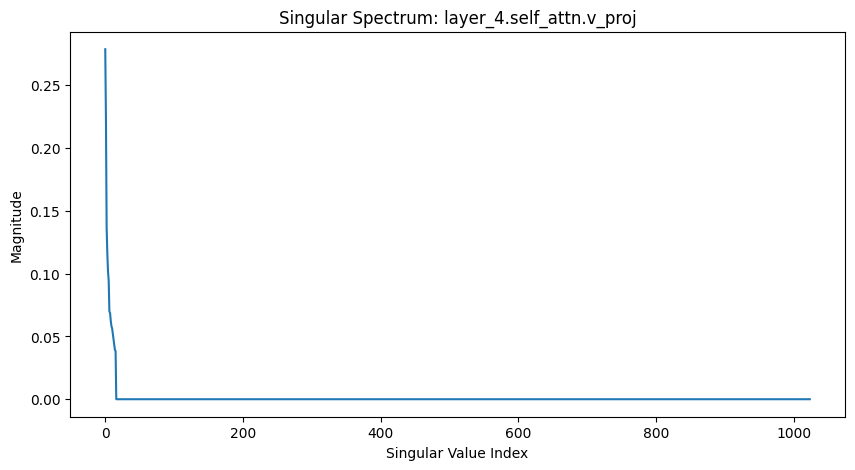

In [29]:
singular_values(deltas_full)

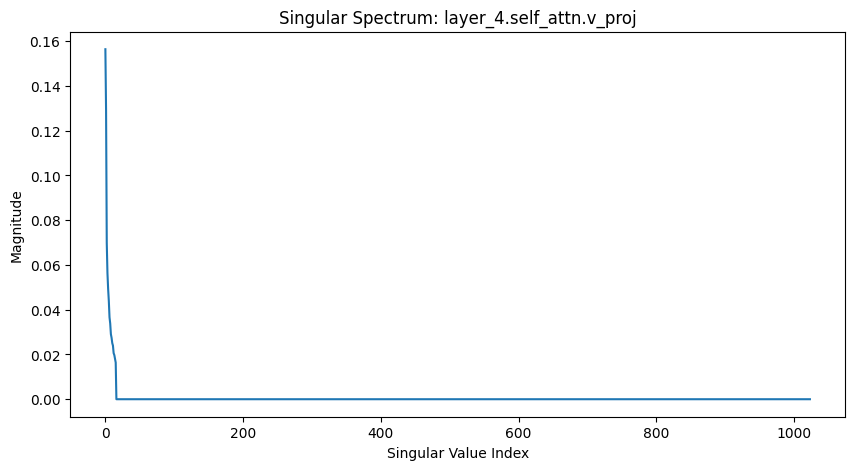

In [30]:
singular_values(deltas_1)

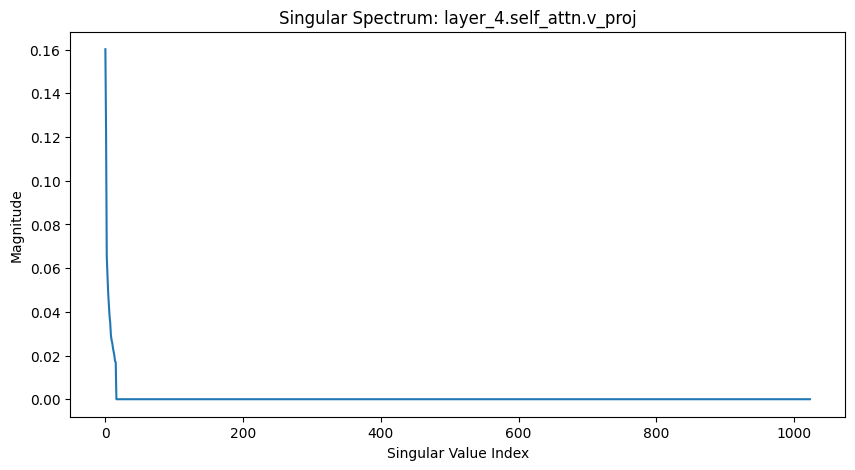

In [31]:
singular_values(deltas_2)

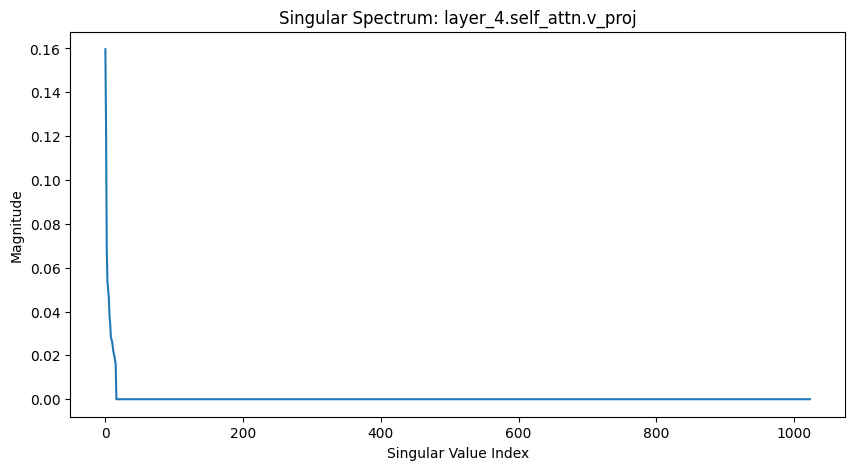

In [32]:
singular_values(deltas_3)

## Effective rank visualization

In [39]:
def effective_rank(singular_values, threshold=0.95):
    energy = singular_values ** 2
    cumulative = np.cumsum(energy)
    total = cumulative[-1]
    ratio = cumulative / total
    rank = np.searchsorted(ratio, threshold) + 1
    return rank

def compute_effective_ranks(adapter_deltas, threshold=0.95):
    ranks = {}
    for layer_name, delta in adapter_deltas.items():
        _, S, _ = torch.svd(delta.float())
        S_np = S.detach().cpu().numpy()
        ranks[layer_name] = effective_rank(S_np, threshold)
    return ranks

In [40]:
def plot_effective_ranks(
    adapter_deltas_list: list[dict],
    labels: list[str],
    colors: list[str] | None = None,
    threshold: float = 0.95,
    layers_per_block: int = 7,
    save_path: str | None = None,
):
    """
    Parameters
    ----------
    adapter_deltas_list : list of dicts mapping layer_name -> delta tensor
    labels              : display name for each adapter
    colors              : optional color per adapter; defaults to matplotlib cycle
    threshold           : cumulative energy threshold for effective rank
    layers_per_block    : number of layers per transformer block (for x-tick labels)
    save_path           : if given, saves the figure to this path
    """
    assert len(adapter_deltas_list) == len(labels), "adapter_deltas_list and labels must be the same length"

    default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    colors = colors or default_colors[: len(labels)]

    # Compute ranks for all adapters
    all_ranks = [compute_effective_ranks(deltas, threshold) for deltas in adapter_deltas_list]

    # Align on common sorted layer names
    layer_names = sorted(all_ranks[0].keys())
    x = np.arange(len(layer_names))

    tick_positions = [i for i in range(len(layer_names)) if i % layers_per_block == 0]
    tick_labels = [f"block_{i // layers_per_block}" for i in tick_positions]

    fig, ax = plt.subplots(figsize=(24, 5))

    for ranks, label, color in zip(all_ranks, labels, colors):
        r = [ranks[l] for l in layer_names]
        ax.plot(x, r, label=label, alpha=0.8, color=color)

    for i in tick_positions:
        ax.axvline(x=i, color="gray", linestyle="--", alpha=0.3)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right")
    ax.set_xlim(0, len(layer_names) - 1)
    ax.set_ylabel("Effective Rank")
    ax.set_xlabel("Block")
    ax.set_title(f"Effective Rank per Layer (threshold={threshold})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()

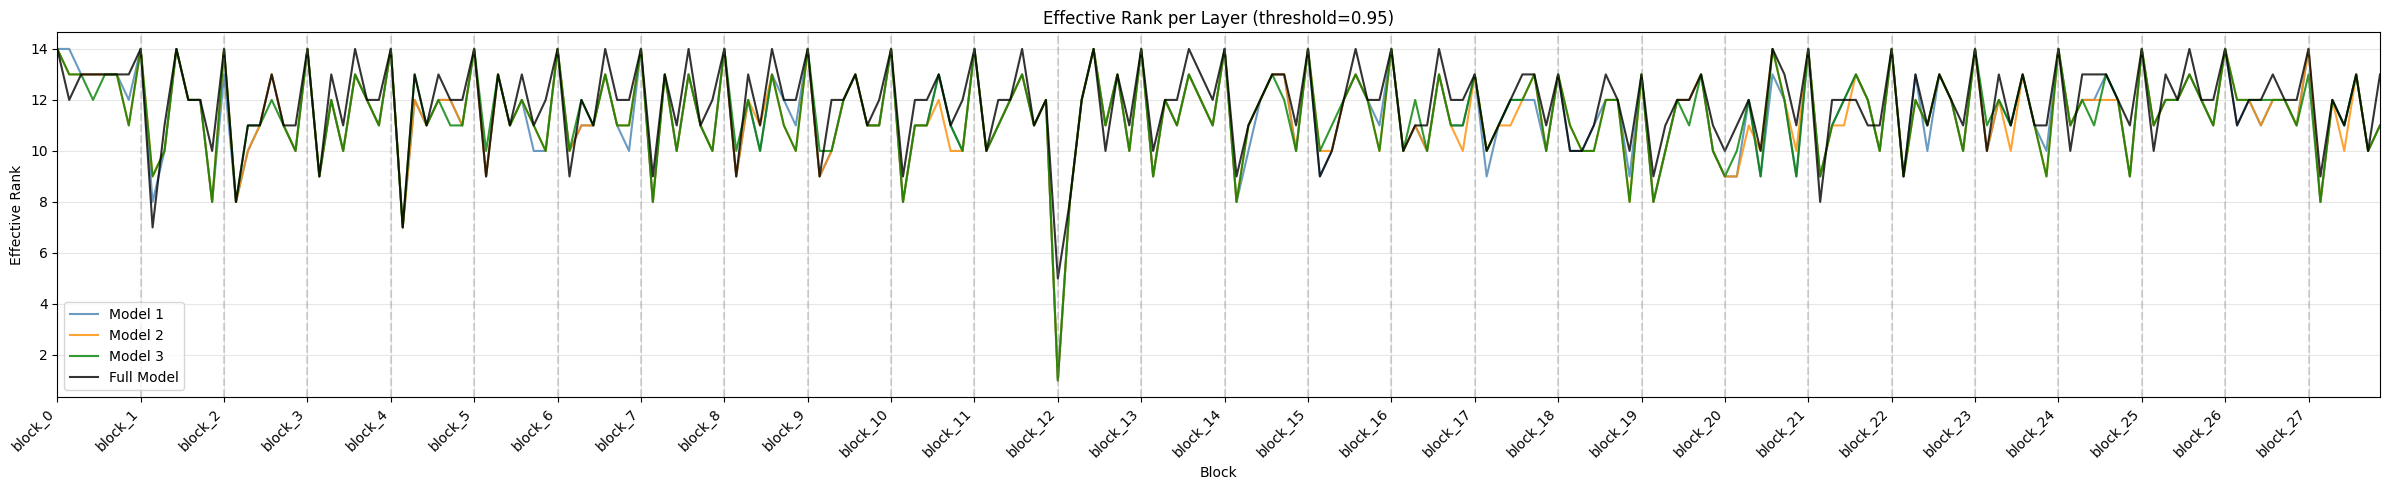

In [41]:
plot_effective_ranks(
    adapter_deltas_list=[deltas_1, deltas_2, deltas_3,deltas_full],
    labels=["Model 1", "Model 2","Model 3","Full Model"],
    colors=["steelblue", "darkorange", "green","black"],
    threshold=0.95,
    layers_per_block=7,
    save_path="effective_rank_all_three_adapters.png",
)